In [1]:
"""
ViT-Small Step 1: Dataset, DataLoaders, and Model Setup.
Reuses the same train_v2/val_v2/test_v2 splits as EfficientNet-B2 for fair comparison.
Jupyter-friendly (NUM_WORKERS=0).
"""
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
from pathlib import Path

In [2]:
# ==================== CONFIG ====================
CODE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work")
IMG_SIZE = 224          # standard ViT-Small input size
BATCH_SIZE = 16
NUM_WORKERS = 0          # Jupyter-safe on Windows
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
 
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [4]:
class BreedDataset(Dataset):
    def __init__(self, csv_path, class_to_idx, transform=None):
        self.df = pd.read_csv(csv_path)
        self.class_to_idx = class_to_idx
        self.transform = transform
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_idx[row["label"]]
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
# ==================== LOAD CLASSES (same as before - for fair comparison) ====================
with open(CODE_DIR / "classes_v2.txt", "r") as f:
    classes = [line.strip() for line in f.readlines()]
NUM_CLASSES = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
print(f"Number of classes: {NUM_CLASSES}")

Number of classes: 62


In [6]:
# ==================== DATASETS (reusing same splits) ====================
train_dataset = BreedDataset(CODE_DIR / "train_v2.csv", class_to_idx, transform=train_transform)
val_dataset = BreedDataset(CODE_DIR / "val_v2.csv", class_to_idx, transform=eval_transform)
test_dataset = BreedDataset(CODE_DIR / "test_v2.csv", class_to_idx, transform=eval_transform)
 
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Train samples: 9752
Val samples: 2090
Test samples: 2090


In [7]:
# ==================== SANITY CHECK ====================
images, labels = next(iter(train_loader))
print(f"\nSample batch -> images: {images.shape}, labels: {labels.shape}")


Sample batch -> images: torch.Size([16, 3, 224, 224]), labels: torch.Size([16])


In [8]:
#==================== MODEL: ViT-Small ====================
# torchvision does NOT ship a "Small" ViT variant (only Base/Large/Huge).
# We use timm's vit_small_patch16_224, the standard ViT-Small (22M params), pretrained on ImageNet.
import timm
 
model = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
 
print(f"\nModel loaded: ViT-Small (timm: vit_small_patch16_224), final layer -> {NUM_CLASSES} classes")
 
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable params: {trainable_params:,}")


Model loaded: ViT-Small (timm: vit_small_patch16_224), final layer -> 62 classes
Total params: 21,689,534 | Trainable params: 21,689,534


In [9]:
# ==================== FORWARD PASS TEST ====================
model.eval()
with torch.no_grad():
    test_out = model(images.to(DEVICE))
print(f"Forward pass output shape: {test_out.shape}  (expected: [{BATCH_SIZE}, {NUM_CLASSES}])")
print("GPU forward pass successful - no OOM at this batch size.")
 

Forward pass output shape: torch.Size([16, 62])  (expected: [16, 62])
GPU forward pass successful - no OOM at this batch size.


# Model Training Code Part

In [10]:
"""
ViT-Small Step 2: Training loop (AdamW, class weights, AMP, early stopping).
Same recipe as EfficientNet-B2 training for a fair, apples-to-apples comparison.
Run AFTER vit_step1_setup.py cell (needs model, loaders, classes, etc. in memory).
"""
 
import torch.nn as nn
import numpy as np
import pandas as pd
import time
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path

In [11]:
# ==================== CONFIG ====================
NUM_EPOCHS = 40
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 6

In [12]:
# ==================== CLASS WEIGHTS ====================
train_df = pd.read_csv(CODE_DIR / "train_v2.csv")
train_labels_idx = train_df["label"].map(class_to_idx).values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_idx
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights: min={class_weights.min().item():.2f}, max={class_weights.max().item():.2f}")

Class weights: min=0.36, max=2.15


In [13]:
# ==================== LOSS, OPTIMIZER, SCALER, SCHEDULER ====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
 
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
 
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
 
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
 
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
 
    return running_loss / total, correct / total

In [15]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)
 
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
 
    return running_loss / total, correct / total

In [16]:
best_val_acc = 0.0
epochs_without_improvement = 0
best_model_path = CODE_DIR / "best_model_v2_vit_small.pth"
history = []
 
print(f"Starting ViT-Small training (max {NUM_EPOCHS} epochs, early stop patience={EARLY_STOP_PATIENCE})...\n")

Starting ViT-Small training (max 40 epochs, early stop patience=6)...



In [17]:
for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()
 
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_acc)
 
    elapsed = time.time() - start_time
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch [{epoch}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.2e} | Time: {elapsed:.1f}s")
 
    history.append({
        "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc, "lr": current_lr
    })
 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": classes,
            "val_acc": val_acc,
            "epoch": epoch
        }, best_model_path)
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement for {epochs_without_improvement} epoch(s)")
 
    # ---- Save history EVERY epoch (not just at the end) - protects against crashes ----
    pd.DataFrame(history).to_csv(CODE_DIR / "training_history_vit_small.csv", index=False)
 
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} "
              f"(no improvement for {EARLY_STOP_PATIENCE} epochs).")
        break
 
print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}")
print(f"Best model saved to: {best_model_path}")
print(f"Training history saved to: {CODE_DIR / 'training_history_vit_small.csv'}")

C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/40] Train Loss: 2.1764 Acc: 0.4015 | Val Loss: 1.4540 Acc: 0.5483 | LR: 1.00e-04 | Time: 497.8s
  -> New best model saved (val_acc=0.5483)


C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/40] Train Loss: 1.1319 Acc: 0.6640 | Val Loss: 1.2219 Acc: 0.6435 | LR: 1.00e-04 | Time: 454.8s
  -> New best model saved (val_acc=0.6435)


C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch [34/40] Train Loss: 0.0774 Acc: 0.9616 | Val Loss: 1.0910 Acc: 0.7856 | LR: 1.25e-05 | Time: 226.1s
  -> No improvement for 4 epoch(s)


C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [35/40] Train Loss: 0.0682 Acc: 0.9658 | Val Loss: 1.0392 Acc: 0.7933 | LR: 1.25e-05 | Time: 225.3s
  -> No improvement for 5 epoch(s)


C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [36/40] Train Loss: 0.0646 Acc: 0.9646 | Val Loss: 1.0559 Acc: 0.7947 | LR: 1.25e-05 | Time: 227.1s
  -> No improvement for 6 epoch(s)

Early stopping triggered at epoch 36 (no improvement for 6 epochs).

Training complete. Best val accuracy: 0.7986
Best model saved to: D:\B.Tech\CE-AI\Sem 7\MP\Code work\best_model_v2_vit_small.pth
Training history saved to: D:\B.Tech\CE-AI\Sem 7\MP\Code work\training_history_vit_small.csv


In [18]:
"""
ViT-Small Step 3: Evaluate on test set. Same metrics as EfficientNet-B2 evaluation for direct comparison.
Jupyter-friendly. Can run in a fresh notebook (self-contained, reloads everything from disk).
"""
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, precision_recall_fscore_support
import timm

In [19]:
# ==================== CONFIG ====================
CODE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work")
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
 
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

Using device: cuda


In [20]:
class BreedDataset(Dataset):
    def __init__(self, csv_path, class_to_idx, transform=None):
        self.df = pd.read_csv(csv_path)
        self.class_to_idx = class_to_idx
        self.transform = transform
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_idx[row["label"]]
        if self.transform:
            image = self.transform(image)
        return image, label

In [21]:
# ==================== LOAD BEST MODEL ====================
checkpoint = torch.load(CODE_DIR / "best_model_v2_vit_small.pth", map_location=DEVICE)
classes = checkpoint["classes"]
NUM_CLASSES = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
 
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.4f}")
 
model = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

Loaded checkpoint from epoch 30, val_acc=0.7986


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [22]:
# ==================== TEST SET ====================
test_dataset = BreedDataset(CODE_DIR / "test_v2.csv", class_to_idx, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f"Test samples: {len(test_dataset)}")

Test samples: 2090


In [23]:
# ==================== RUN INFERENCE ====================
all_preds, all_labels, all_probs = [], [], []
 
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
 
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
 
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [24]:
# ==================== METRICS ====================
test_acc = (all_preds == all_labels).mean()
top3_acc = top_k_accuracy_score(all_labels, all_probs, k=3, labels=np.arange(NUM_CLASSES))
top5_acc = top_k_accuracy_score(all_labels, all_probs, k=5, labels=np.arange(NUM_CLASSES))
 
print(f"\n{'='*50}")
print(f"ViT-Small Test Accuracy (Top-1): {test_acc:.4f}")
print(f"ViT-Small Test Accuracy (Top-3): {top3_acc:.4f}")
print(f"ViT-Small Test Accuracy (Top-5): {top5_acc:.4f}")
print(f"{'='*50}")


ViT-Small Test Accuracy (Top-1): 0.7885
ViT-Small Test Accuracy (Top-3): 0.9220
ViT-Small Test Accuracy (Top-5): 0.9569


In [25]:
# ---- Per-class classification report ----
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]
report = classification_report(all_labels, all_preds, target_names=target_names,
                                 digits=3, zero_division=0)
print("\nPer-class classification report:\n")
print(report)
 
report_path = CODE_DIR / "classification_report_vit_small.txt"
with open(report_path, "w") as f:
    f.write(f"Test Accuracy (Top-1): {test_acc:.4f}\n")
    f.write(f"Test Accuracy (Top-3): {top3_acc:.4f}\n")
    f.write(f"Test Accuracy (Top-5): {top5_acc:.4f}\n\n")
    f.write(report)
print(f"Saved classification report to: {report_path}")


Per-class classification report:

                          precision    recall  f1-score   support

        buffalo_alambadi      0.961     0.942     0.951        52
           buffalo_banni      0.774     0.774     0.774        31
          buffalo_bargur      0.273     0.333     0.300        27
       buffalo_bhadawari      0.886     0.886     0.886        35
     buffalo_jaffarabadi      0.964     0.844     0.900        32
         buffalo_mehsana      0.686     0.889     0.774        27
          buffalo_murrah      0.712     0.725     0.718        51
         buffalo_nagpuri      0.750     0.652     0.698        46
       buffalo_nili_ravi      0.900     0.750     0.818        24
           buffalo_surti      0.667     0.824     0.737        17
            buffalo_toda      0.611     0.611     0.611        18
       cattle_amritmahal      0.867     0.907     0.886        43
         cattle_ayrshire      0.891     0.872     0.882        94
          cattle_bachaur      0.667     

Saved confusion matrix to: D:\B.Tech\CE-AI\Sem 7\MP\Code work\confusion_matrix_vit_small.png


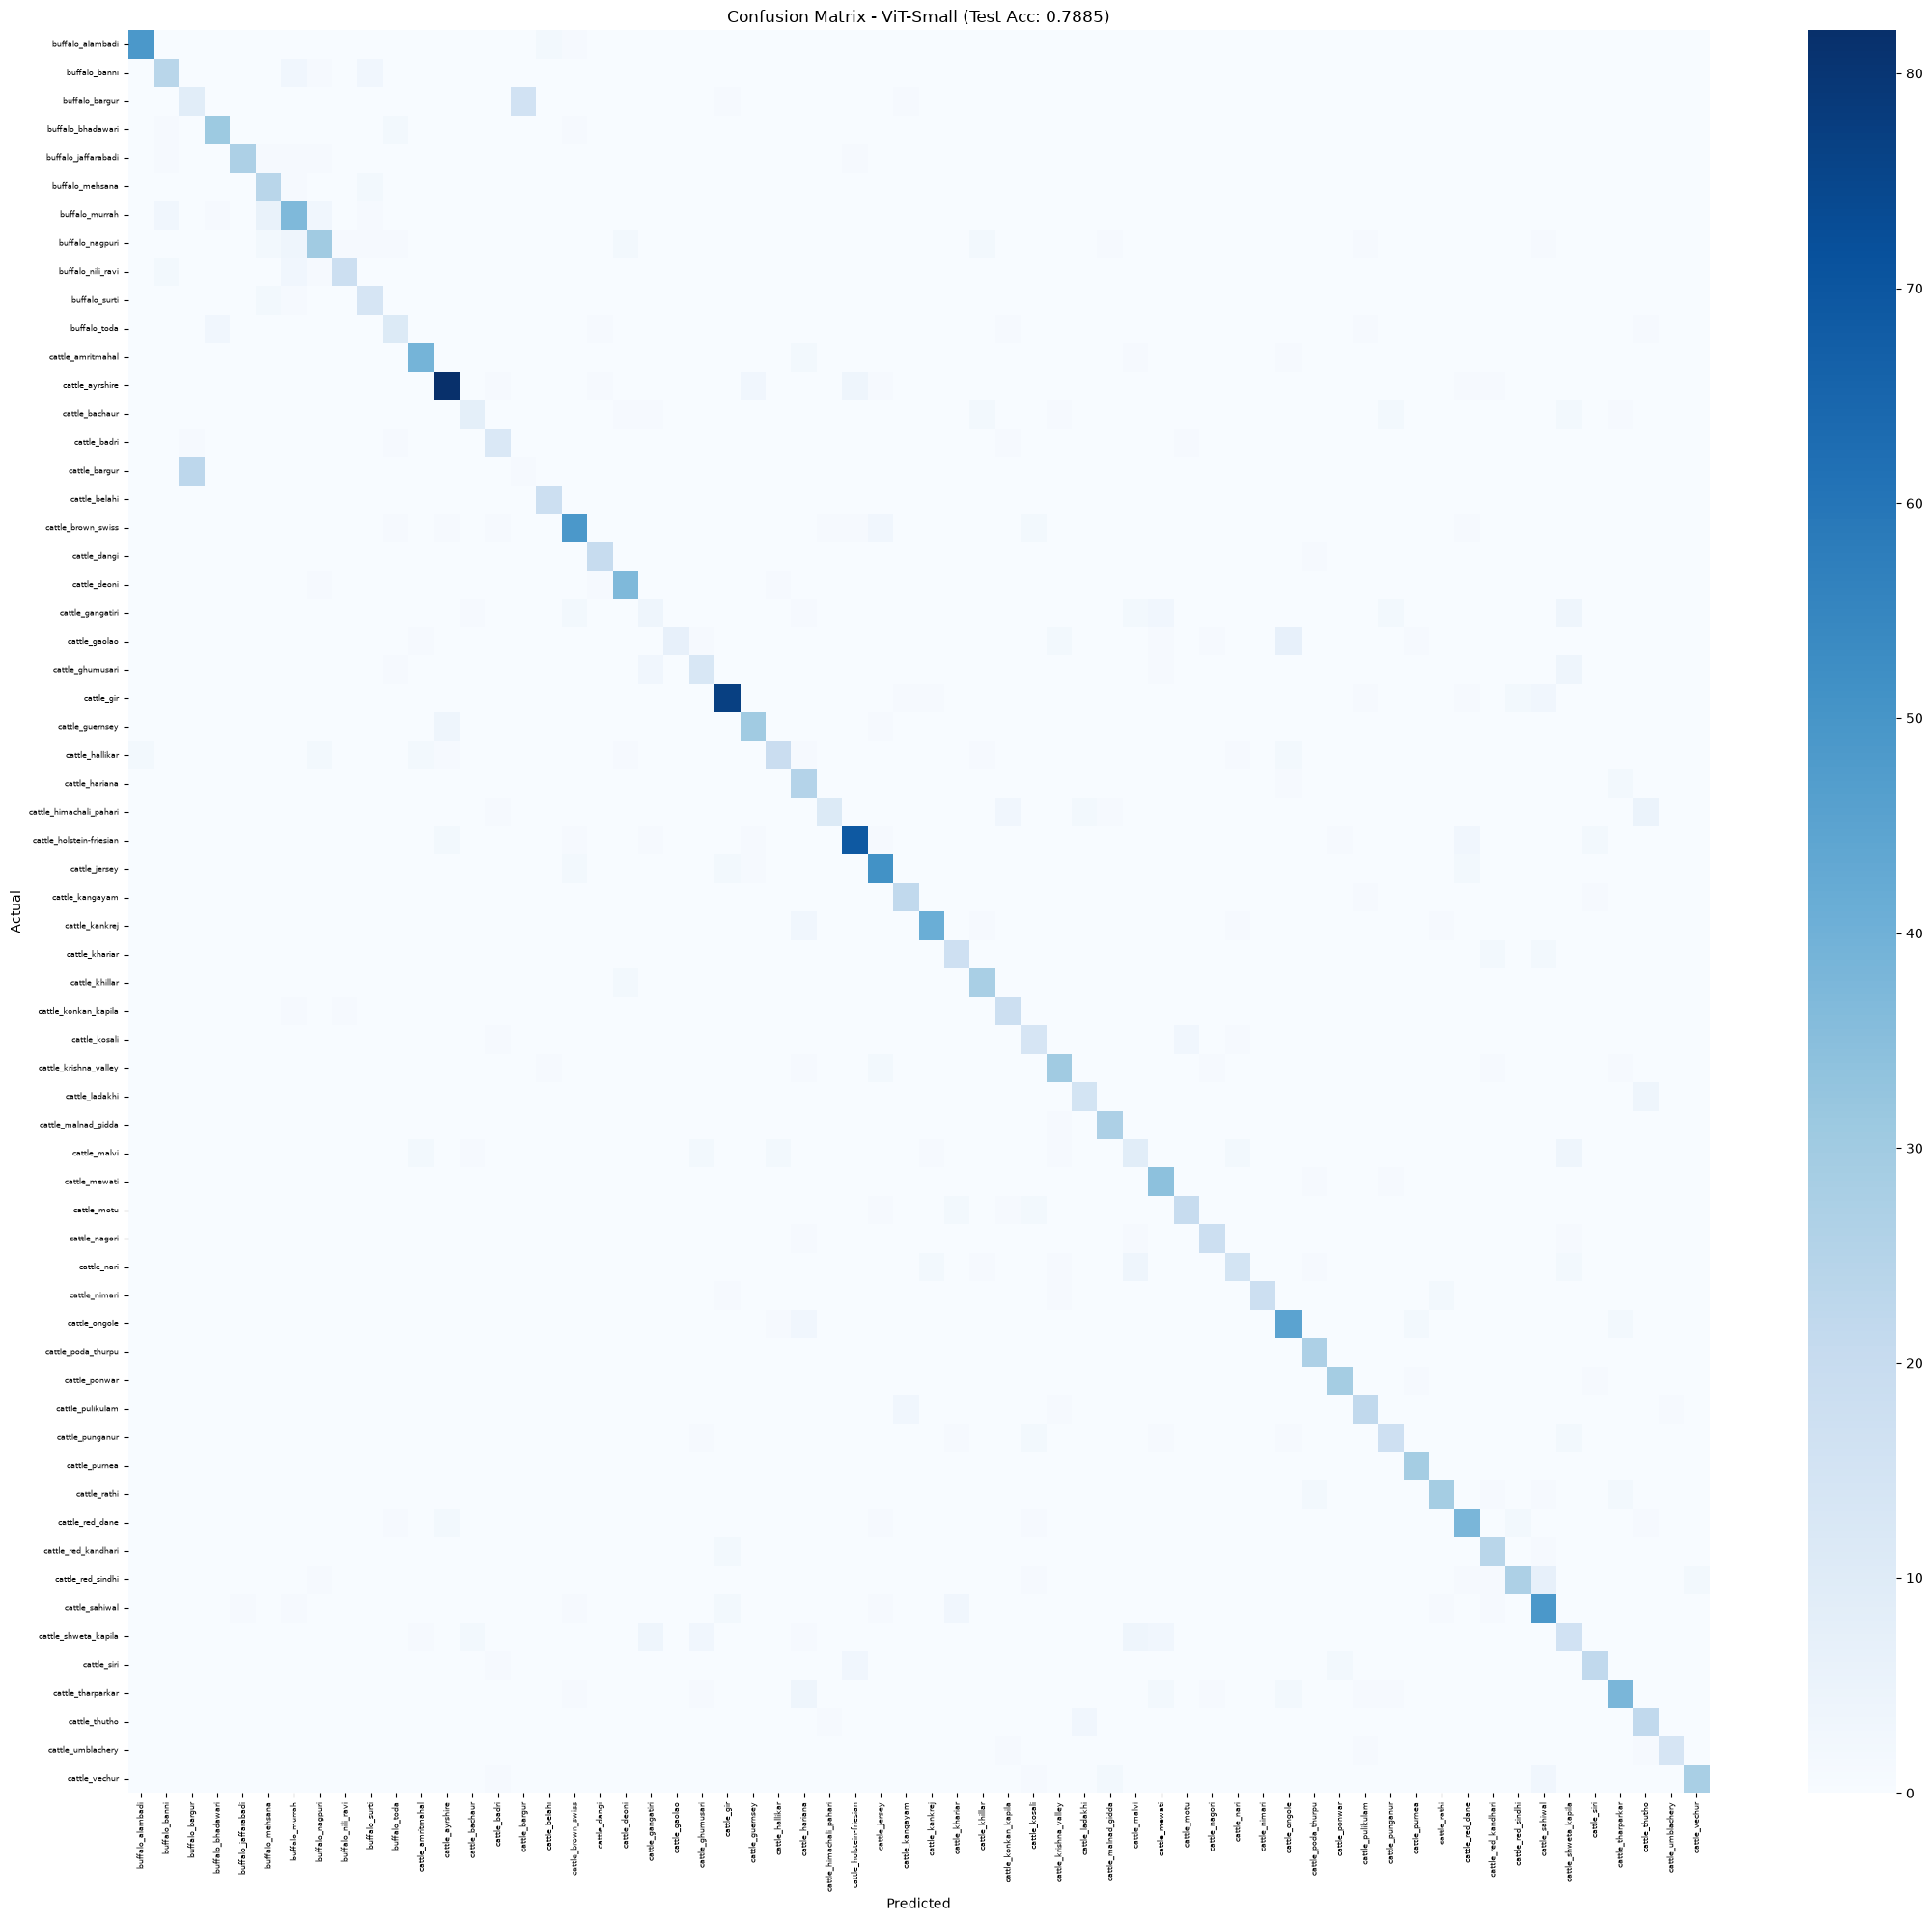

In [26]:
# ==================== CONFUSION MATRIX ====================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(22, 20))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - ViT-Small (Test Acc: {test_acc:.4f})")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
cm_path = CODE_DIR / "confusion_matrix_vit_small.png"
plt.savefig(cm_path, dpi=150)
print(f"Saved confusion matrix to: {cm_path}")
plt.show()

In [27]:
# ==================== BEST/WORST CLASSES ====================
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=np.arange(NUM_CLASSES), zero_division=0
)
per_class_df = pd.DataFrame({
    "class": target_names,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
}).sort_values("f1_score")
 
print("\n--- 10 Worst Performing Classes (by F1) ---")
print(per_class_df.head(10).to_string(index=False))
 
print("\n--- 10 Best Performing Classes (by F1) ---")
print(per_class_df.tail(10).to_string(index=False))
 
per_class_df.to_csv(CODE_DIR / "per_class_metrics_vit_small.csv", index=False)
print(f"\nSaved per-class metrics to: {CODE_DIR / 'per_class_metrics_vit_small.csv'}")


--- 10 Worst Performing Classes (by F1) ---
                  class  precision   recall  f1_score  support
          cattle_bargur   0.058824 0.041667  0.048780       24
       cattle_gangatiri   0.307692 0.210526  0.250000       19
         buffalo_bargur   0.272727 0.333333  0.300000       27
           cattle_malvi   0.428571 0.375000  0.400000       24
   cattle_shweta_kapila   0.457143 0.470588  0.463768       34
          cattle_gaolao   1.000000 0.333333  0.500000       21
         cattle_bachaur   0.666667 0.444444  0.533333       18
       cattle_ghumusari   0.619048 0.590909  0.604651       22
cattle_himachali_pahari   0.846154 0.478261  0.611111       23
           buffalo_toda   0.611111 0.611111  0.611111       18

--- 10 Best Performing Classes (by F1) ---
              class  precision   recall  f1_score  support
buffalo_jaffarabadi   0.964286 0.843750  0.900000       32
      cattle_nimari   1.000000 0.818182  0.900000       22
         cattle_gir   0.905882 0.895349  

Loaded 36 epochs of history
    epoch  train_loss  train_acc  val_loss   val_acc        lr
31     32    0.075600   0.960623  1.028305  0.785646  0.000025
32     33    0.077441   0.960111  1.050333  0.788517  0.000025
33     34    0.077430   0.961649  1.091032  0.785646  0.000013
34     35    0.068248   0.965751  1.039152  0.793301  0.000013
35     36    0.064604   0.964623  1.055932  0.794737  0.000013

Saved training curves to: D:\B.Tech\CE-AI\Sem 7\MP\Code work\training_curves_vit_small.png


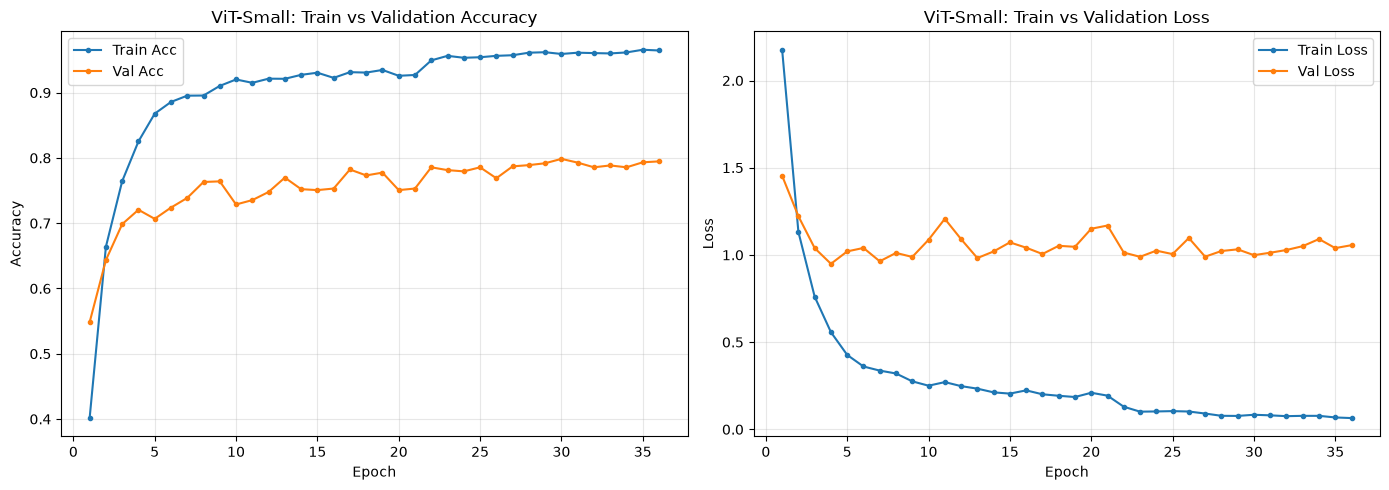

In [1]:
"""
Plot Train/Val Loss and Accuracy curves for ViT-Small.
Reads from training_history_vit_small.csv (saved during training).
Jupyter-friendly, self-contained.
"""
 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
 
CODE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work")
 
history = pd.read_csv(CODE_DIR / "training_history_vit_small.csv")
print(f"Loaded {len(history)} epochs of history")
print(history.tail())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# ---- Accuracy plot ----
axes[0].plot(history["epoch"], history["train_acc"], label="Train Acc", marker="o", markersize=3)
axes[0].plot(history["epoch"], history["val_acc"], label="Val Acc", marker="o", markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("ViT-Small: Train vs Validation Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)
 
# ---- Loss plot ----
axes[1].plot(history["epoch"], history["train_loss"], label="Train Loss", marker="o", markersize=3)
axes[1].plot(history["epoch"], history["val_loss"], label="Val Loss", marker="o", markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("ViT-Small: Train vs Validation Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
curves_path = CODE_DIR / "training_curves_vit_small.png"
plt.savefig(curves_path, dpi=150)
print(f"\nSaved training curves to: {curves_path}")
plt.show()